# **Vehicle Carbon Emission Prediction using Regression**

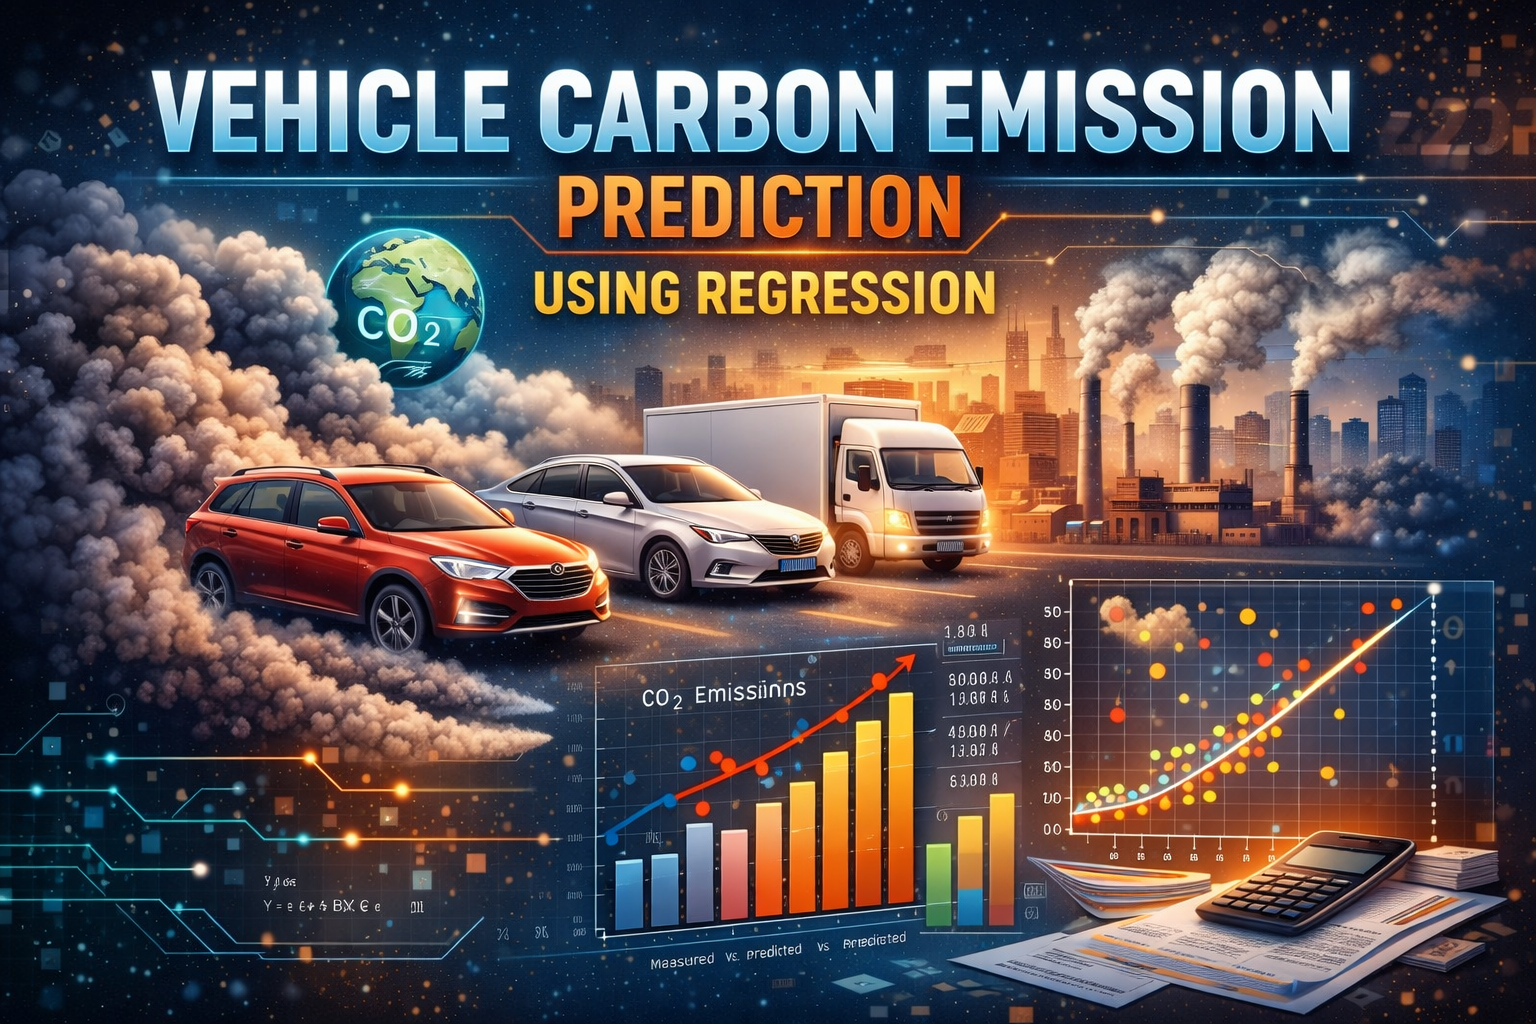

#### This project aims to predict vehicle carbon dioxide (CO₂) emissions using regression-based machine learning models. By analyzing vehicle-related features such as engine size, fuel consumption, cylinders, and fuel type, the model learns the relationship between these variables and the amount of CO₂ emitted. The trained regression model can estimate the expected carbon emission of a vehicle, which helps in understanding environmental impact and supports the development of more eco-friendly transportation systems.
#### The dataset used in this project contains various technical specifications of vehicles along with their corresponding CO₂ emission values. Important features typically include engine size, number of cylinders, fuel consumption in city/highway/combined conditions, and fuel type. These attributes are used as input variables, while CO₂ emissions (g/km) act as the target variable for prediction. The dataset enables the regression model to identify patterns between vehicle characteristics and their carbon emission levels.

## **IMPORTING LIBRARIES**

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

## **IMPORTING DATASET**

In [ ]:
df = pd.read_csv('/content/vehicle_data_large.csv')
df

,Vehicle_ID,Engine_Size,Cylinders,Fuel_Type,City_MPG,Highway_MPG,CO2_Emissions
0,1,2.5,4,Diesel,37.3,42.4,280.0
1,2,4.8,4,Gasoline,31.1,34.8,245.0
2,3,3.9,4,Gasoline,48.8,52.7,108.0
3,4,3.4,6,Diesel,22.7,27.0,410.0
4,5,1.6,4,Gasoline,35.6,40.0,196.0
...,...,...,...,...,...,...,...
9995,9996,4.4,6,Hybrid,41.4,48.8,271.0
9996,9997,4.6,3,Diesel,41.8,46.4,159.0
9997,9998,4.8,4,Gasoline,24.4,32.6,225.0
9998,9999,2.6,4,Gasoline,30.2,36.8,218.0


## **DATA PREPROCESSING**

### Check Missing Values

In [ ]:
df.isna().sum()

,0
Vehicle_ID,0
Engine_Size,0
Cylinders,0
Fuel_Type,0
City_MPG,0
Highway_MPG,0
CO2_Emissions,0


### Check Duplicates

In [ ]:
df.drop_duplicates()

,Vehicle_ID,Engine_Size,Cylinders,Fuel_Type,City_MPG,Highway_MPG,CO2_Emissions
0,1,2.5,4,Diesel,37.3,42.4,280.0
1,2,4.8,4,Gasoline,31.1,34.8,245.0
2,3,3.9,4,Gasoline,48.8,52.7,108.0
3,4,3.4,6,Diesel,22.7,27.0,410.0
4,5,1.6,4,Gasoline,35.6,40.0,196.0
...,...,...,...,...,...,...,...
9995,9996,4.4,6,Hybrid,41.4,48.8,271.0
9996,9997,4.6,3,Diesel,41.8,46.4,159.0
9997,9998,4.8,4,Gasoline,24.4,32.6,225.0
9998,9999,2.6,4,Gasoline,30.2,36.8,218.0


### Check Datatypes

In [ ]:
df.dtypes

,0
Vehicle_ID,int64
Engine_Size,float64
Cylinders,int64
Fuel_Type,object
City_MPG,float64
Highway_MPG,float64
CO2_Emissions,float64


### Encoding Objects

In [ ]:
encoder = LabelEncoder()
df['Fuel_Type'] = encoder.fit_transform(df['Fuel_Type'])

### Deleting Unnecessary columns

In [ ]:
df.drop('Vehicle_ID', axis=1, inplace=True)

In [ ]:
df

,Engine_Size,Cylinders,Fuel_Type,City_MPG,Highway_MPG,CO2_Emissions
0,2.5,4,0,37.3,42.4,280.0
1,4.8,4,1,31.1,34.8,245.0
2,3.9,4,1,48.8,52.7,108.0
3,3.4,6,0,22.7,27.0,410.0
4,1.6,4,1,35.6,40.0,196.0
...,...,...,...,...,...,...
9995,4.4,6,2,41.4,48.8,271.0
9996,4.6,3,0,41.8,46.4,159.0
9997,4.8,4,1,24.4,32.6,225.0
9998,2.6,4,1,30.2,36.8,218.0


## **SEPERATING FEATURE AND DATASET**

In [ ]:
x = df.iloc[:, :-1]
x

,Engine_Size,Cylinders,Fuel_Type,City_MPG,Highway_MPG
0,2.5,4,0,37.3,42.4
1,4.8,4,1,31.1,34.8
2,3.9,4,1,48.8,52.7
3,3.4,6,0,22.7,27.0
4,1.6,4,1,35.6,40.0
...,...,...,...,...,...
9995,4.4,6,2,41.4,48.8
9996,4.6,3,0,41.8,46.4
9997,4.8,4,1,24.4,32.6
9998,2.6,4,1,30.2,36.8


In [ ]:
y = df.iloc[:, -1]
y

,CO2_Emissions
0,280.0
1,245.0
2,108.0
3,410.0
4,196.0
...,...
9995,271.0
9996,159.0
9997,225.0
9998,218.0


## **SCALING**

In [ ]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[0.375     , 0.2       , 0.        , 0.63714286, 0.58373206],
       [0.95      , 0.2       , 0.5       , 0.46      , 0.40191388],
       [0.725     , 0.2       , 0.5       , 0.96571429, 0.83014354],
       ...,
       [0.95      , 0.2       , 0.5       , 0.26857143, 0.3492823 ],
       [0.4       , 0.2       , 0.5       , 0.43428571, 0.44976077],
       [0.225     , 0.2       , 0.5       , 0.48857143, 0.55263158]])

## **TRAIN TEST SPLIT**

In [ ]:
x_test, x_train, y_test, y_train = train_test_split(x_scaled, y, test_size=0.3, random_state=1)

# **Simple Linear Regression**

### **MODEL CREATION AND FITTING**

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

### **PREDICTION**

In [ ]:
y_pred = lr.predict(x_test)
y_pred

array([189.04772552, 318.26481595, 236.9186253 , ..., 182.09555366,
       331.54330703, 363.79356141])

### **EVALUATION**

In [ ]:
print(r2_score(y_test, y_pred)*100)

44.86233379837298


# **Polynomial Regression**

In [ ]:
poly = PolynomialFeatures(degree=7)
x_poly = poly.fit_transform(x)
x_poly

array([[1.00000000e+00, 2.50000000e+00, 4.00000000e+00, ...,
        1.90654450e+11, 2.16722485e+11, 2.46354782e+11],
       [1.00000000e+00, 4.80000000e+00, 4.00000000e+00, ...,
        4.93647563e+10, 5.52377338e+10, 6.18094256e+10],
       [1.00000000e+00, 3.90000000e+00, 4.00000000e+00, ...,
        9.68038701e+11, 1.04540245e+12, 1.12894896e+12],
       ...,
       [1.00000000e+00, 4.80000000e+00, 4.00000000e+00, ...,
        2.19213680e+10, 2.92883851e+10, 3.91312031e+10],
       [1.00000000e+00, 2.60000000e+00, 4.00000000e+00, ...,
        6.15535322e+10, 7.50056286e+10, 9.13975871e+10],
       [1.00000000e+00, 1.90000000e+00, 4.00000000e+00, ...,
        1.20842353e+11, 1.54723387e+11, 1.98103776e+11]])

### **MODEL CREATION AND FITTING**

In [ ]:
plr = LinearRegression()
plr.fit(x_poly, y)

LinearRegression()

### **PREDICTION**

In [ ]:
y_pred1 = plr.predict(x_poly)
y_pred1

array([209.5839866 , 237.56542297, 155.43747456, ..., 275.14584966,
       234.37293847, 220.09426649])

### **EVALUATION**

In [ ]:
print(r2_score(y, y_pred1)*100)

51.06981078553907
